# IV Fluids Drop Count Heatmap

This notebook implements a heatmap-based approach for IV fluids drop counting and analysis.


This cell initializes the environment for heatmap-based IV drop detection. It imports fundamental scientific computing libraries such as NumPy, Pandas, OpenCV, and Matplotlib. It also imports the core PyTorch modules required for defining the neural network architecture, data loaders, and transformations. Finally, it checks for GPU availability, reporting the device type and available memory to ensure hardware acceleration is active.

In [1]:
"""
IV Drop Detection - Heatmap-Based Training
==========================================
Architecture: ResNet18 + Custom Heatmap Head
Dataset: 3,458 annotated images (Split: 70% Train / 20% Val / 10% Test)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path
from tqdm.notebook import tqdm
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.transforms import functional as F
from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")


Using device: cuda
GPU: Tesla T4
Memory: 14.6 GB


This cell establishes the overarching configuration for the training pipeline. A centralized `Config` class is defined, encapsulating essential paths (e.g., input directories, save locations), model hyperparameters (e.g., ResNet18 backbone, learning rate, epochs, batch size), and dataset split ratios (70% train, 20% validation, 10% test). Reproducibility is enforced by setting deterministic seeds across NumPy, Python's `random`, and PyTorch.

In [2]:
"""
Training Configuration
"""
from sklearn.model_selection import train_test_split  

class Config:
    DATA_DIR = "/kaggle/input/iv-fluids-drop-detection-dataset-heatmaps/dataset"
    IMAGES_DIR = os.path.join(DATA_DIR, "images")
    HEATMAPS_DIR = os.path.join(DATA_DIR, "heatmaps")

    IMG_SIZE = 416
    GRID_SIZE = 26
    BACKBONE = 'resnet18'

    BATCH_SIZE = 32
    EPOCHS = 100
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 1e-5

    
    TRAIN_SPLIT = 0.70
    VAL_SPLIT   = 0.20
    TEST_SPLIT  = 0.10

    NUM_WORKERS = 4
    PIN_MEMORY = True

    SAVE_DIR = "checkpoints"
    BEST_MODEL = "best_heatmap_model.pth"
    SAVE_EVERY = 10
    PATIENCE = 20
    SEED = 42

random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
torch.cuda.manual_seed_all(Config.SEED)

os.makedirs(Config.SAVE_DIR, exist_ok=True)
print("Configuration loaded successfully!")
print(f"Dataset split: Train {Config.TRAIN_SPLIT*100:.0f}% / "
      f"Val {Config.VAL_SPLIT*100:.0f}% / Test {Config.TEST_SPLIT*100:.0f}%")


Configuration loaded successfully!
Dataset split: Train 70% / Val 20% / Test 10%


This cell dynamically auto-discovers the dataset directories (images and corresponding heatmaps) by traversing the standard Kaggle input structure. It verifies the dataset integrity by comparing file counts, ensuring that every input image has a corresponding ground-truth heatmap. It also inspects a sample heatmap to validate its shape against the grid size defined in the configuration, and performs a rapid sampling to summarize the distribution of empty versus drop-containing instances.

In [3]:
"""
CELL 3 — Auto-discover dataset paths + Verify integrity
"""
from glob import glob
import os


print("Scanning Kaggle input for dataset structure...")

INPUT_ROOT = "/kaggle/input"
found_images_dir = None
found_heatmaps_dir = None

for root, dirs, files in os.walk(INPUT_ROOT):
    if "images" in dirs and found_images_dir is None:
        candidate = os.path.join(root, "images")
        imgs = glob(os.path.join(candidate, "*.jpg")) +               glob(os.path.join(candidate, "*.png"))
        if imgs:
            found_images_dir = candidate
            print(f"  ✓ Found images dir : {found_images_dir} ({len(imgs)} files)")

    if "heatmaps" in dirs and found_heatmaps_dir is None:
        candidate = os.path.join(root, "heatmaps")
        hmaps = glob(os.path.join(candidate, "*.npy"))
        if hmaps:
            found_heatmaps_dir = candidate
            print(f"  ✓ Found heatmaps dir: {found_heatmaps_dir} ({len(hmaps)} files)")

    if found_images_dir and found_heatmaps_dir:
        break


if not found_images_dir or not found_heatmaps_dir:
    print("\n[WARNING] Could not auto-detect. Printing directory tree:\n")
    for root, dirs, files in os.walk(INPUT_ROOT):
        depth = root.replace(INPUT_ROOT, '').count(os.sep)
        indent = '  ' * depth
        print(f"{indent}{os.path.basename(root)}/")
        if depth < 4:  
            for f in files[:5]:
                print(f"{indent}  {f}")
    raise FileNotFoundError(
        "Could not find images/heatmaps directories. "
        "Check the tree above and update Config.IMAGES_DIR and Config.HEATMAPS_DIR manually."
    )


Config.IMAGES_DIR   = found_images_dir
Config.HEATMAPS_DIR = found_heatmaps_dir
print(f"\nConfig paths updated:")
print(f"  IMAGES_DIR   = {Config.IMAGES_DIR}")
print(f"  HEATMAPS_DIR = {Config.HEATMAPS_DIR}")


image_files   = sorted(glob(os.path.join(Config.IMAGES_DIR,   "*.jpg")) +
                        glob(os.path.join(Config.IMAGES_DIR,   "*.png")))
heatmap_files = sorted(glob(os.path.join(Config.HEATMAPS_DIR, "*.npy")))

print(f"\nTotal images  : {len(image_files)}")
print(f"Total heatmaps: {len(heatmap_files)}")
print(f"Counts match  : {len(image_files) == len(heatmap_files)}")

if len(heatmap_files) == 0:
    raise FileNotFoundError(
        f"No .npy files found in {Config.HEATMAPS_DIR}. "
        "The heatmaps may use a different format or sub-folder."
    )


sample_heatmap = np.load(heatmap_files[0])
print(f"\nSample heatmap shape : {sample_heatmap.shape}")
print(f"Expected shape       : ({Config.GRID_SIZE}, {Config.GRID_SIZE})")
print(f"Shape correct        : {sample_heatmap.shape == (Config.GRID_SIZE, Config.GRID_SIZE)}")

drop_count = 0; empty_count = 0
for hm_file in tqdm(heatmap_files[:500], desc="Sampling dataset"):
    hm = np.load(hm_file)
    if hm.max() > 0.1:
        drop_count += 1
    else:
        empty_count += 1

print(f"\nSample distribution (first 500):")
print(f"  With drops : {drop_count} ({drop_count/5:.1f}%)")
print(f"  Empty      : {empty_count} ({empty_count/5:.1f}%)")


Scanning Kaggle input for dataset structure...
  ✓ Found images dir : /kaggle/input/datasets/nishanthegde2315/iv-fluids-drop-detection-dataset-heatmaps/dataset/images (3458 files)
  ✓ Found heatmaps dir: /kaggle/input/datasets/nishanthegde2315/iv-fluids-drop-detection-dataset-heatmaps/dataset/heatmaps (3458 files)

Config paths updated:
  IMAGES_DIR   = /kaggle/input/datasets/nishanthegde2315/iv-fluids-drop-detection-dataset-heatmaps/dataset/images
  HEATMAPS_DIR = /kaggle/input/datasets/nishanthegde2315/iv-fluids-drop-detection-dataset-heatmaps/dataset/heatmaps

Total images  : 3458
Total heatmaps: 3458
Counts match  : True

Sample heatmap shape : (26, 26)
Expected shape       : (26, 26)
Shape correct        : True


Sampling dataset:   0%|          | 0/500 [00:00<?, ?it/s]


Sample distribution (first 500):
  With drops : 408 (81.6%)
  Empty      : 92 (18.4%)


This cell defines a custom PyTorch Dataset class, `DropHeatmapDataset`. It inherits from `torch.utils.data.Dataset` and manages the synchronized loading of image frames and their corresponding `.npy` heatmaps. It implements optional online data augmentation (such as horizontal flipping, brightness adjustments, and contrast variations) exclusively during training to enhance model robustness. Standardization transforms are also initialized to scale images correctly for the ResNet18 backbone.

In [4]:
"""
Custom Dataset for Heatmap Training
"""
class DropHeatmapDataset(Dataset):
    def __init__(self, image_files, heatmap_files, transform=None, augment=False):
        self.image_files = image_files
        self.heatmap_files = heatmap_files
        self.transform = transform
        self.augment = augment
        for img_f, hm_f in zip(image_files, heatmap_files):
            assert Path(img_f).stem == Path(hm_f).stem,                f"Mismatch: {Path(img_f).stem} != {Path(hm_f).stem}"

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_files[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        heatmap = np.load(self.heatmap_files[idx]).astype(np.float32)
        if self.augment:
            image, heatmap = self.augment_data(image, heatmap)
        if self.transform:
            image = self.transform(image)
        heatmap = torch.from_numpy(heatmap).unsqueeze(0)
        return image, heatmap

    def augment_data(self, image, heatmap):
        if random.random() > 0.5:
            image = cv2.flip(image, 1)
            heatmap = np.flip(heatmap, axis=1).copy()
        if random.random() > 0.5:
            factor = random.uniform(0.8, 1.2)
            image = np.clip(image * factor, 0, 255).astype(np.uint8)
        if random.random() > 0.5:
            factor = random.uniform(0.8, 1.2)
            mean = image.mean()
            image = np.clip((image - mean) * factor + mean, 0, 255).astype(np.uint8)
        return image, heatmap

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Dataset class defined successfully!")


Dataset class defined successfully!


This cell executes a rigorous stratified split of the dataset into Training (70%), Validation (20%), and Held-out Test (10%) sets. It computes stratification labels based on the maximum heatmap activation (i.e., whether a drop is present or not) to ensure balanced class distributions across all splits. It subsequently instantiates the respective `DropHeatmapDataset` objects and wraps them in PyTorch `DataLoader` instances with multi-processing and pinned memory enabled for optimized data pipelining.

In [5]:
"""
Split dataset into Train (70%) / Val (20%) / Test (10%) sets
Using stratified split to match YOLOv8 notebook methodology
"""
from sklearn.model_selection import train_test_split


image_files = sorted(glob(os.path.join(Config.IMAGES_DIR, "*.jpg")))
heatmap_files = sorted(glob(os.path.join(Config.HEATMAPS_DIR, "*.npy")))

matched_files = []
for img_f in image_files:
    hm_f = os.path.join(Config.HEATMAPS_DIR, f"{Path(img_f).stem}.npy")
    if os.path.exists(hm_f):
        matched_files.append((img_f, hm_f))

print(f"Total matched files: {len(matched_files)}")


print("Building stratification labels...")
strat_labels = []
for _, hm_f in tqdm(matched_files, desc="Labelling"):
    hm = np.load(hm_f)
    strat_labels.append(1 if hm.max() > 0.1 else 0)
strat_labels = np.array(strat_labels)


train_val_files, test_files, train_val_labels, _ = train_test_split(
    matched_files, strat_labels,
    test_size=Config.TEST_SPLIT,
    random_state=Config.SEED,
    stratify=strat_labels
)


val_fraction = Config.VAL_SPLIT / (Config.TRAIN_SPLIT + Config.VAL_SPLIT)
train_files, val_files = train_test_split(
    train_val_files,
    test_size=val_fraction,
    random_state=Config.SEED,
    stratify=train_val_labels
)

print(f"\nDataset split (seed={Config.SEED}):")
print(f"  Training : {len(train_files):4d} images ({len(train_files)/len(matched_files)*100:.1f}%)")
print(f"  Validation: {len(val_files):4d} images ({len(val_files)/len(matched_files)*100:.1f}%)")
print(f"  Test      : {len(test_files):4d} images ({len(test_files)/len(matched_files)*100:.1f}%)")


train_dataset = DropHeatmapDataset(
    [f[0] for f in train_files], [f[1] for f in train_files],
    transform=train_transform, augment=True
)
val_dataset = DropHeatmapDataset(
    [f[0] for f in val_files], [f[1] for f in val_files],
    transform=val_test_transform, augment=False
)
test_dataset = DropHeatmapDataset(     
    [f[0] for f in test_files], [f[1] for f in test_files],
    transform=val_test_transform, augment=False
)


train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE,
                          shuffle=True,  num_workers=Config.NUM_WORKERS,
                          pin_memory=Config.PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=Config.BATCH_SIZE,
                          shuffle=False, num_workers=Config.NUM_WORKERS,
                          pin_memory=Config.PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=Config.BATCH_SIZE,  
                          shuffle=False, num_workers=Config.NUM_WORKERS,
                          pin_memory=Config.PIN_MEMORY)

print(f"\nDataLoaders created:")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")


Total matched files: 3458
Building stratification labels...


Labelling:   0%|          | 0/3458 [00:00<?, ?it/s]


Dataset split (seed=42):
  Training : 2420 images (70.0%)
  Validation:  692 images (20.0%)
  Test      :  346 images (10.0%)

DataLoaders created:
  Train batches : 76
  Val batches   : 22
  Test batches  : 11


This cell defines the primary neural network architecture, `HeatmapDropDetector`. The model utilizes a pre-trained ResNet18 backbone (omitting the fully connected classification head) to perform high-level feature extraction. It appends a custom heatmap regression head consisting of sequential convolutional layers with batch normalization and dropout, progressively refining the spatial features. A final sigmoid activation and adaptive average pooling are applied to output a localized 2D spatial heatmap matching the configured grid size.

In [6]:
"""
Heatmap Detection Model
Architecture: ResNet18 backbone + Custom heatmap head
"""

class HeatmapDropDetector(nn.Module):
    """
    Drop detector with heatmap output
    Based on paper's approach but using ResNet18 backbone
    """
    
    def __init__(self, grid_size=26, pretrained=True):
        super(HeatmapDropDetector, self).__init__()
        
        self.grid_size = grid_size
        
        
        resnet = models.resnet18(pretrained=pretrained)
        
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        
        
        backbone_out_channels = 512
        
        
        self.heatmap_head = nn.Sequential(
            
            nn.Conv2d(backbone_out_channels, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.2),
            
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.2),
            
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            
            nn.Conv2d(64, 1, kernel_size=1),
            nn.Sigmoid()  
        )
        
        
        self.adaptive_pool = nn.AdaptiveAvgPool2d((grid_size, grid_size))
    
    def forward(self, x):
        
        features = self.backbone(x)  
        
        
        heatmap = self.heatmap_head(features)  
        
        
        heatmap = self.adaptive_pool(heatmap)  
        
        return heatmap



model = HeatmapDropDetector(grid_size=Config.GRID_SIZE, pretrained=True)
model = model.to(device)


total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model created successfully!")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: ~{total_params * 4 / 1024**2:.1f} MB")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


Model created successfully!
Total parameters: 12,726,209
Trainable parameters: 12,726,209
Model size: ~48.5 MB


This cell initializes the optimization strategy. The Mean Squared Error (MSE) loss function is selected to penalize deviations between the predicted and ground-truth heatmaps. The Adam optimizer is configured with the predefined learning rate and weight decay (L2 regularization). Additionally, a `ReduceLROnPlateau` scheduler is deployed to dynamically attenuate the learning rate if the validation loss stagnates, thereby facilitating fine-grained convergence.

In [7]:
"""
Loss function and optimizer setup
"""

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=Config.LEARNING_RATE,
    weight_decay=Config.WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=10
    
)

print("Optimizer and scheduler configured!")
print(f"Initial learning rate: {Config.LEARNING_RATE}")


Optimizer and scheduler configured!
Initial learning rate: 0.001


This cell defines the core iteration functions for model training and validation. The `train_epoch` function sets the model to training mode, propagates batches through the network, computes gradients via backpropagation, and updates the optimizer weights. The `validate_epoch` function operates identically but under `torch.no_grad()` to compute the validation loss purely for performance tracking without altering model parameters.

In [8]:
"""
Training and validation functions
"""

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    
    pbar = tqdm(dataloader, desc="Training")
    for images, heatmaps in pbar:
        images = images.to(device)
        heatmaps = heatmaps.to(device)
        
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, heatmaps)
        
        
        loss.backward()
        optimizer.step()
        
        
        running_loss += loss.item() * images.size(0)
        pbar.set_postfix({'loss': f'{loss.item():.6f}'})
    
    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss


def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Validation")
        for images, heatmaps in pbar:
            images = images.to(device)
            heatmaps = heatmaps.to(device)
            
            
            outputs = model(images)
            loss = criterion(outputs, heatmaps)
            
            
            running_loss += loss.item() * images.size(0)
            pbar.set_postfix({'loss': f'{loss.item():.6f}'})
    
    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss


print("Training functions defined!")

Training functions defined!


This cell executes the comprehensive end-to-end training loop. It iterates over the specified number of epochs, invoking the training and validation routines. It enforces early stopping mechanisms by monitoring the validation loss with a defined patience threshold to prevent overfitting. Concurrently, it saves checkpoint models when performance improves, logs essential metrics into a history dictionary, and dynamically plots real-time loss and learning rate decay graphs to monitor convergence.

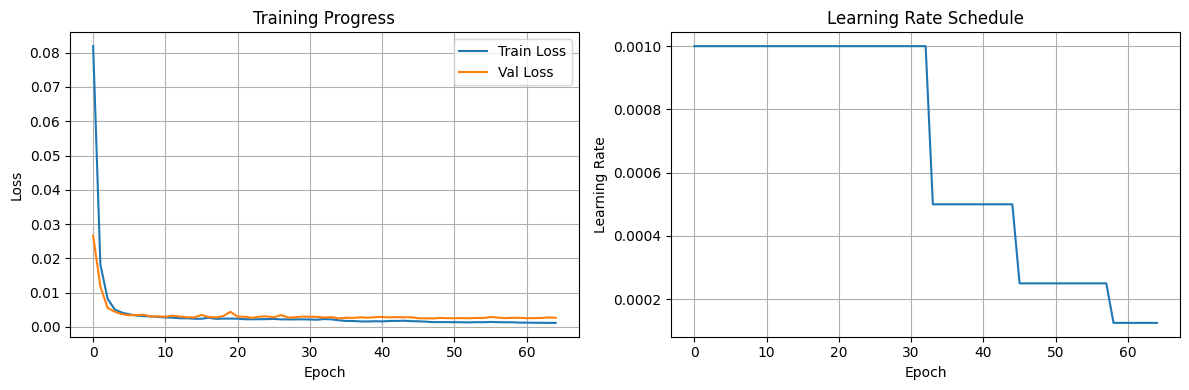


Epoch 66/100
------------------------------------------------------------


Training:   0%|          | 0/76 [00:00<?, ?it/s]

Validation:   0%|          | 0/22 [00:00<?, ?it/s]


Epoch 66 Summary:
  Train Loss: 0.001170
  Val Loss:   0.002575
  LR:         0.000125
  No improvement (18/20)

Epoch 67/100
------------------------------------------------------------


Training:   0%|          | 0/76 [00:00<?, ?it/s]

Validation:   0%|          | 0/22 [00:00<?, ?it/s]


Epoch 67 Summary:
  Train Loss: 0.001165
  Val Loss:   0.002708
  LR:         0.000125
  No improvement (19/20)

Epoch 68/100
------------------------------------------------------------


Training:   0%|          | 0/76 [00:00<?, ?it/s]

Validation:   0%|          | 0/22 [00:00<?, ?it/s]


Epoch 68 Summary:
  Train Loss: 0.001157
  Val Loss:   0.002692
  LR:         0.000125
  No improvement (20/20)

[EARLY STOPPING] No improvement for 20 epochs

TRAINING COMPLETE!
Best validation loss: 0.002451


In [9]:
"""
Main training loop with checkpointing and monitoring
"""


history = {
    'train_loss': [],
    'val_loss': [],
    'learning_rates': []
}


best_val_loss = float('inf')
patience_counter = 0

print("Starting training...")
print("="*60)

for epoch in range(Config.EPOCHS):
    print(f"\nEpoch {epoch+1}/{Config.EPOCHS}")
    print("-" * 60)
    
    
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    
    
    val_loss = validate_epoch(model, val_loader, criterion, device)
    
    
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['learning_rates'].append(current_lr)
    
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.6f}")
    print(f"  Val Loss:   {val_loss:.6f}")
    print(f"  LR:         {current_lr:.6f}")
    
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'best_val_loss': best_val_loss,
        }, os.path.join(Config.SAVE_DIR, Config.BEST_MODEL))
        print(f"  ✓ Best model saved! (Val loss: {val_loss:.6f})")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{Config.PATIENCE})")
    
    
    if (epoch + 1) % Config.SAVE_EVERY == 0:
        checkpoint_path = os.path.join(Config.SAVE_DIR, f"checkpoint_epoch_{epoch+1}.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
        }, checkpoint_path)
        print(f"  ✓ Checkpoint saved: {checkpoint_path}")
    
    
    if patience_counter >= Config.PATIENCE:
        print(f"\n[EARLY STOPPING] No improvement for {Config.PATIENCE} epochs")
        break
    
    
    if (epoch + 1) % 5 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        plt.plot(history['train_loss'], label='Train Loss')
        plt.plot(history['val_loss'], label='Val Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Progress')
        plt.legend()
        plt.grid(True)
        
        plt.subplot(1, 2, 2)
        plt.plot(history['learning_rates'])
        plt.xlabel('Epoch')
        plt.ylabel('Learning Rate')
        plt.title('Learning Rate Schedule')
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print(f"Best validation loss: {best_val_loss:.6f}")

This cell visualizes the final aggregated training statistics using Matplotlib. It plots the progression of both training and validation MSE losses alongside the learning rate decay schedule over all epochs. It also calculates and visualizes the validation loss improvement curve, assisting in the visual diagnosis of model convergence characteristics.

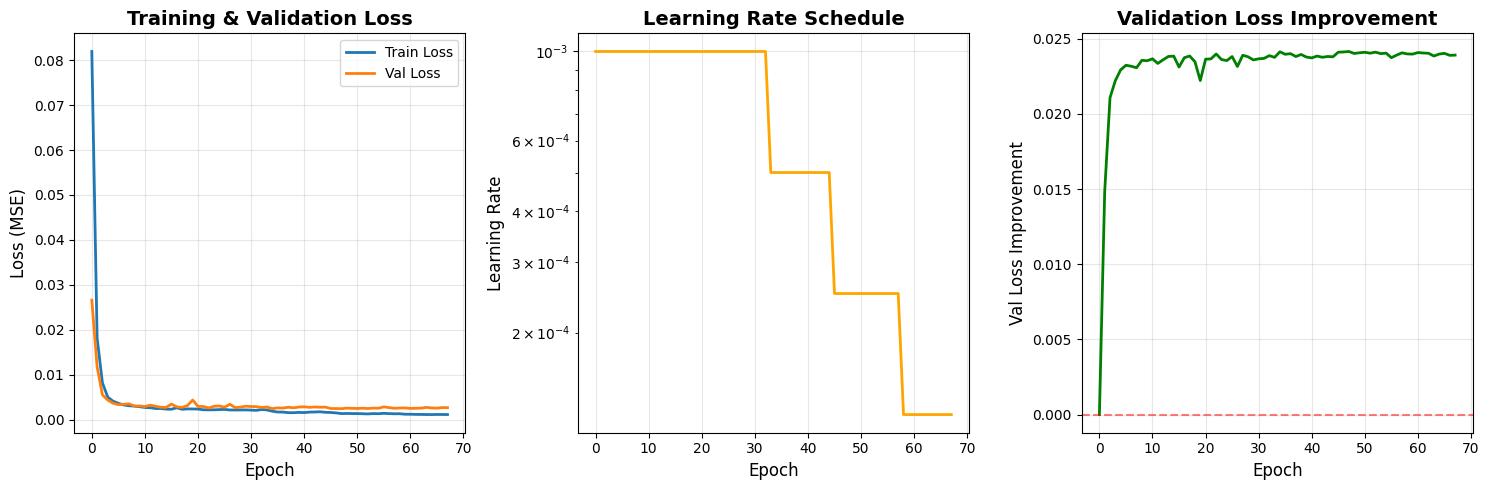

FINAL TRAINING STATISTICS
Total epochs trained: 68
Best validation loss: 0.002451
Final train loss: 0.001157
Final val loss: 0.002692
Improvement: 0.024145


In [10]:
"""
Visualize final training results
"""

plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training & Validation Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)


plt.subplot(1, 3, 2)
plt.plot(history['learning_rates'], linewidth=2, color='orange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.title('Learning Rate Schedule', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.yscale('log')


plt.subplot(1, 3, 3)
improvements = [history['val_loss'][0] - loss for loss in history['val_loss']]
plt.plot(improvements, linewidth=2, color='green')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Val Loss Improvement', fontsize=12)
plt.title('Validation Loss Improvement', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


print("FINAL TRAINING STATISTICS")
print("="*60)
print(f"Total epochs trained: {len(history['train_loss'])}")
print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Final train loss: {history['train_loss'][-1]:.6f}")
print(f"Final val loss: {history['val_loss'][-1]:.6f}")
print(f"Improvement: {history['val_loss'][0] - best_val_loss:.6f}")
print("="*60)

This cell evaluates the qualitative performance of the optimal model checkpoint on the held-out test dataset. It restores the best model parameters from the saved file and processes a randomized sample subset. The output generated compares the original input image, the ground-truth target heatmap, and the model's predicted spatial heatmap side-by-side to visually inspect the accuracy of the drop localization.

Loaded best model from epoch 48
Best validation loss: 0.002451


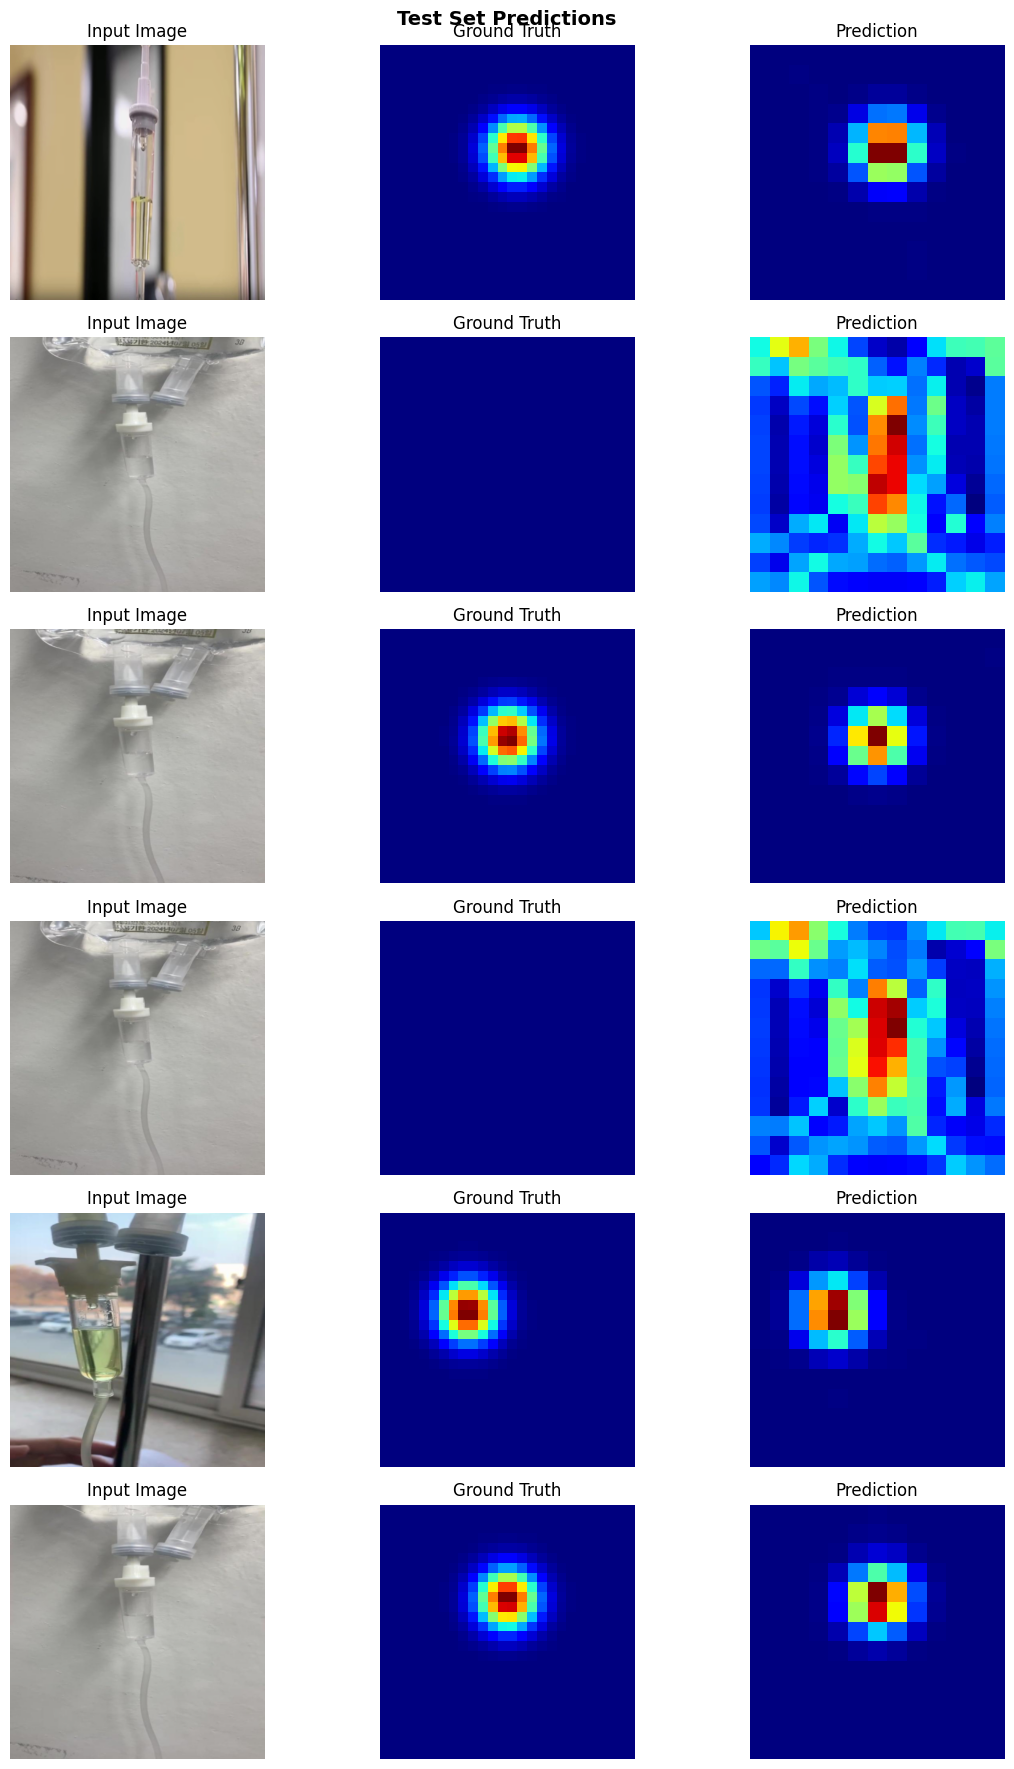

In [11]:
"""
Load best model and visualize predictions on HELD-OUT TEST SET
"""
checkpoint = torch.load(os.path.join(Config.SAVE_DIR, Config.BEST_MODEL))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Best validation loss: {checkpoint['best_val_loss']:.6f}")

def visualize_predictions(model, dataset, num_samples=6, title_prefix="Test"):
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples*3))
    indices = random.sample(range(len(dataset)), num_samples)
    model.eval()
    with torch.no_grad():
        for idx, data_idx in enumerate(indices):
            image, gt_heatmap = dataset[data_idx]
            image_batch = image.unsqueeze(0).to(device)
            pred_heatmap = model(image_batch)[0, 0].cpu().numpy()
            img_display = image.permute(1, 2, 0).numpy()
            img_display = img_display * np.array([0.229, 0.224, 0.225])                        + np.array([0.485, 0.456, 0.406])
            img_display = np.clip(img_display, 0, 1)
            gt_heatmap = gt_heatmap[0].numpy()
            axes[idx, 0].imshow(img_display);  axes[idx, 0].set_title('Input Image');  axes[idx, 0].axis('off')
            axes[idx, 1].imshow(gt_heatmap, cmap='jet'); axes[idx, 1].set_title('Ground Truth'); axes[idx, 1].axis('off')
            axes[idx, 2].imshow(pred_heatmap, cmap='jet'); axes[idx, 2].set_title('Prediction');   axes[idx, 2].axis('off')
    plt.suptitle(f'{title_prefix} Set Predictions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{title_prefix.lower()}_predictions_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()


visualize_predictions(model, test_dataset, num_samples=6, title_prefix="Test")


This cell conducts a rigorous quantitative evaluation on the strictly held-out test split (10% of data). It computes global regression metrics including Mean Squared Error (MSE) and Mean Absolute Error (MAE). Furthermore, it calculates a binary classification detection accuracy by thresholding the peak heatmap activation values, offering an interpretable metric representing how often a fluid drop is correctly identified.

In [12]:
"""
Quantitative evaluation on HELD-OUT TEST SET (10%, 346 images)
"""
def evaluate_model(model, dataloader, device, threshold=0.3):
    model.eval()
    total_mse = 0; total_mae = 0; correct_detections = 0; total_samples = 0
    with torch.no_grad():
        for images, heatmaps in tqdm(dataloader, desc="Evaluating"):
            images = images.to(device); heatmaps = heatmaps.to(device)
            outputs = model(images)
            total_mse += ((outputs - heatmaps) ** 2).mean().item() * images.size(0)
            total_mae += (outputs - heatmaps).abs().mean().item() * images.size(0)
            for i in range(images.size(0)):
                gt_has_drop   = heatmaps[i].max() > 0.1
                pred_has_drop = outputs[i].max()  > threshold
                if gt_has_drop == pred_has_drop:
                    correct_detections += 1
                total_samples += 1
    return (total_mse / len(dataloader.dataset),
            total_mae / len(dataloader.dataset),
            correct_detections / total_samples)


print("Evaluating on HELD-OUT TEST SET...")
test_mse, test_mae, test_acc = evaluate_model(model, test_loader, device)

print("\n" + "="*60)
print("TEST SET METRICS (Held-Out 10% — 346 images)")
print("="*60)
print(f"Mean Squared Error (MSE): {test_mse:.6f}")
print(f"Mean Absolute Error (MAE): {test_mae:.6f}")
print(f"Detection Accuracy:        {test_acc*100:.2f}%")
print("="*60)
print("Copy these numbers to Table 3 in your paper!")


Evaluating on HELD-OUT TEST SET...


Evaluating:   0%|          | 0/11 [00:00<?, ?it/s]


TEST SET METRICS (Held-Out 10% — 346 images)
Mean Squared Error (MSE): 0.002450
Mean Absolute Error (MAE): 0.014083
Detection Accuracy:        89.31%
Copy these numbers to Table 3 in your paper!


This cell handles the final model serialization and artifact export. The fully trained model weights, alongside crucial architectural configurations, training history, and quantitative test metrics, are bundled into a comprehensive checkpoint file. The raw training history is also exported to a CSV file to facilitate any future off-line analysis.

In [13]:
"""
Save final model for inference
"""
final_model_path = "drop_detector_final.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'img_size': Config.IMG_SIZE,
        'grid_size': Config.GRID_SIZE,
        'backbone': Config.BACKBONE,
        'dataset_split': '70:20:10',   
        'test_size': len(test_dataset) 
    },
    'metrics': {
        'best_val_loss': best_val_loss,
        
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_detection_accuracy': test_acc
    },
    'training_history': history
}, final_model_path)

print(f"Final model saved: {final_model_path}")
pd.DataFrame(history).to_csv('training_history.csv', index=False)
print("Training history saved: training_history.csv")
print("\nTRAINING COMPLETE! Model ready for deployment!")


Final model saved: drop_detector_final.pth
Training history saved: training_history.csv

TRAINING COMPLETE! Model ready for deployment!


This cell executes a deep-dive comprehensive performance analysis on the test set predictions. It calculates extensive classification metrics (Accuracy, Precision, Recall, F1-Score, and Specificity) based on a predefined activation threshold. It leverages Seaborn to render standard and normalized confusion matrices, frequency distributions of heatmap scores, and a Receiver Operating Characteristic (ROC) curve outlining the trade-off between True Positive and False Positive rates.

Evaluating:   0%|          | 0/11 [00:00<?, ?it/s]

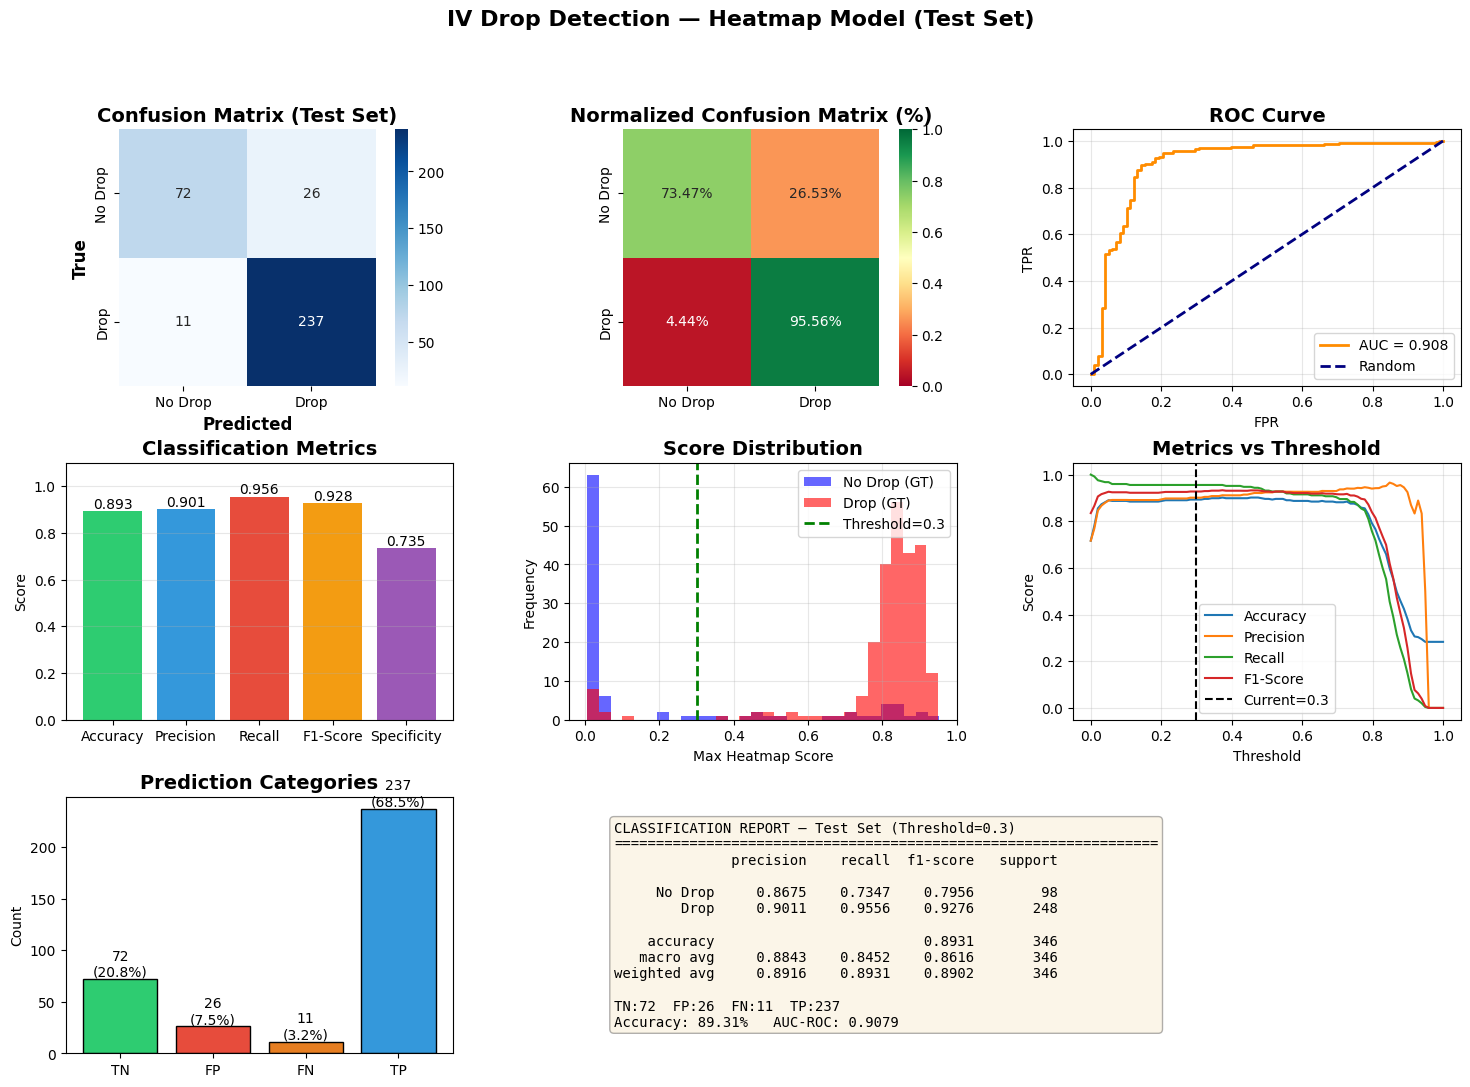


FINAL METRICS — TEST SET (346 images)
Accuracy:    0.8931 (89.31%)
Precision:   0.9011 (90.11%)
Recall:      0.9556 (95.56%)
F1-Score:    0.9276 (92.76%)
Specificity: 0.7347 (73.47%)
AUC-ROC:     0.9079
>>> Copy these numbers to Table 3 in the paper! <<<


In [14]:
"""
Comprehensive Performance Analysis on HELD-OUT TEST SET
"""
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

def generate_confusion_matrix_and_plots(model, dataloader, device, threshold=0.3,
                                         split_name="Test"):
    model.eval()
    all_gt_labels = []; all_pred_labels = []; all_pred_scores = []

    print(f"Collecting predictions on {split_name} set...")
    with torch.no_grad():
        for images, heatmaps in tqdm(dataloader, desc="Evaluating"):
            images = images.to(device); heatmaps = heatmaps.to(device)
            outputs = model(images)
            for i in range(images.size(0)):
                gt_has_drop  = (heatmaps[i].max() > 0.1).cpu().item()
                pred_score   = outputs[i].max().cpu().item()
                pred_has_drop = pred_score > threshold
                all_gt_labels.append(int(gt_has_drop))
                all_pred_labels.append(int(pred_has_drop))
                all_pred_scores.append(pred_score)

    all_gt_labels   = np.array(all_gt_labels)
    all_pred_labels = np.array(all_pred_labels)
    all_pred_scores = np.array(all_pred_scores)

    fig = plt.figure(figsize=(18, 12))
    gs  = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    
    ax1 = fig.add_subplot(gs[0, 0])
    cm  = confusion_matrix(all_gt_labels, all_pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, square=True,
                xticklabels=['No Drop','Drop'], yticklabels=['No Drop','Drop'])
    ax1.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    ax1.set_ylabel('True', fontsize=12, fontweight='bold')
    ax1.set_title(f'Confusion Matrix ({split_name} Set)', fontsize=14, fontweight='bold')

    
    ax2 = fig.add_subplot(gs[0, 1])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn', ax=ax2, square=True,
                vmin=0, vmax=1, xticklabels=['No Drop','Drop'], yticklabels=['No Drop','Drop'])
    ax2.set_title('Normalized Confusion Matrix (%)', fontsize=14, fontweight='bold')

    
    ax3 = fig.add_subplot(gs[0, 2])
    fpr, tpr, _ = roc_curve(all_gt_labels, all_pred_scores)
    roc_auc = auc(fpr, tpr)
    ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    ax3.plot([0,1],[0,1], color='navy', lw=2, linestyle='--', label='Random')
    ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
    ax3.set_title('ROC Curve', fontsize=14, fontweight='bold')
    ax3.legend(loc='lower right'); ax3.grid(True, alpha=0.3)

    
    ax4 = fig.add_subplot(gs[1, 0])
    tn, fp, fn, tp = cm.ravel()
    accuracy    = (tp+tn)/(tp+tn+fp+fn)
    precision   = tp/(tp+fp) if (tp+fp)>0 else 0
    recall      = tp/(tp+fn) if (tp+fn)>0 else 0
    f1          = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0
    specificity = tn/(tn+fp) if (tn+fp)>0 else 0
    metrics_dict = {'Accuracy':accuracy,'Precision':precision,
                    'Recall':recall,'F1-Score':f1,'Specificity':specificity}
    bars = ax4.bar(metrics_dict.keys(), metrics_dict.values(),
                   color=['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6'])
    ax4.set_ylim([0,1.1]); ax4.set_ylabel('Score')
    ax4.set_title('Classification Metrics', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    for bar in bars:
        h = bar.get_height()
        ax4.text(bar.get_x()+bar.get_width()/2., h, f'{h:.3f}', ha='center', va='bottom')

    
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.hist(all_pred_scores[all_gt_labels==0], bins=30, alpha=0.6, label='No Drop (GT)', color='blue')
    ax5.hist(all_pred_scores[all_gt_labels==1], bins=30, alpha=0.6, label='Drop (GT)',    color='red')
    ax5.axvline(threshold, color='green', linestyle='--', lw=2, label=f'Threshold={threshold}')
    ax5.set_xlabel('Max Heatmap Score'); ax5.set_ylabel('Frequency')
    ax5.set_title('Score Distribution', fontsize=14, fontweight='bold')
    ax5.legend(); ax5.grid(True, alpha=0.3)

    
    ax6 = fig.add_subplot(gs[1, 2])
    ts = np.linspace(0, 1, 100)
    accs, precs, recs, f1s = [], [], [], []
    for t in ts:
        pl = (all_pred_scores > t).astype(int)
        ct = confusion_matrix(all_gt_labels, pl).ravel()
        tn_t,fp_t,fn_t,tp_t = ct
        a = (tp_t+tn_t)/(tp_t+tn_t+fp_t+fn_t)
        p = tp_t/(tp_t+fp_t) if (tp_t+fp_t)>0 else 0
        r = tp_t/(tp_t+fn_t) if (tp_t+fn_t)>0 else 0
        f = 2*p*r/(p+r) if (p+r)>0 else 0
        accs.append(a); precs.append(p); recs.append(r); f1s.append(f)
    ax6.plot(ts, accs, label='Accuracy'); ax6.plot(ts, precs, label='Precision')
    ax6.plot(ts, recs, label='Recall');   ax6.plot(ts, f1s,  label='F1-Score')
    ax6.axvline(threshold, color='black', linestyle='--', label=f'Current={threshold}')
    ax6.set_xlabel('Threshold'); ax6.set_ylabel('Score')
    ax6.set_title('Metrics vs Threshold', fontsize=14, fontweight='bold')
    ax6.legend(); ax6.grid(True, alpha=0.3)

    
    ax7 = fig.add_subplot(gs[2, 0])
    cats = ['TN','FP','FN','TP']; counts = [tn,fp,fn,tp]
    colors = ['#2ecc71','#e74c3c','#e67e22','#3498db']
    bars7 = ax7.bar(cats, counts, color=colors, edgecolor='black')
    ax7.set_ylabel('Count'); ax7.set_title('Prediction Categories', fontsize=14, fontweight='bold')
    for b in bars7:
        h = b.get_height()
        ax7.text(b.get_x()+b.get_width()/2., h,
                 f'{int(h)}\n({h/sum(counts)*100:.1f}%)', ha='center', va='bottom')

    
    ax8 = fig.add_subplot(gs[2, 1:])
    ax8.axis('off')
    report = classification_report(all_gt_labels, all_pred_labels,
                                   target_names=['No Drop','Drop'], digits=4)
    report_text = (f"CLASSIFICATION REPORT — {split_name} Set "
                   f"(Threshold={threshold})\n{'='*65}\n{report}\n"
                   f"TN:{tn}  FP:{fp}  FN:{fn}  TP:{tp}\n"
                   f"Accuracy: {accuracy*100:.2f}%   AUC-ROC: {roc_auc:.4f}")
    ax8.text(0.05, 0.5, report_text, fontsize=10, family='monospace',
             verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.suptitle(f'IV Drop Detection — Heatmap Model ({split_name} Set)',
                 fontsize=16, fontweight='bold')
    plt.savefig(f'heatmap_{split_name.lower()}_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n" + "="*70)
    print(f"FINAL METRICS — {split_name.upper()} SET ({len(all_gt_labels)} images)")
    print("="*70)
    print(f"Accuracy:    {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision:   {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall:      {recall:.4f} ({recall*100:.2f}%)")
    print(f"F1-Score:    {f1:.4f} ({f1*100:.2f}%)")
    print(f"Specificity: {specificity:.4f} ({specificity*100:.2f}%)")
    print(f"AUC-ROC:     {roc_auc:.4f}")
    print("="*70)
    print(">>> Copy these numbers to Table 3 in the paper! <<<")
    return cm, {'accuracy':accuracy,'precision':precision,'recall':recall,'f1':f1}, roc_auc


cm, metrics, roc_auc = generate_confusion_matrix_and_plots(
    model, test_loader, device, threshold=0.3, split_name="Test"
)


This cell aggregates all validation visualizations into a unified final performance dashboard. It reproduces the training loss curves and learning rate schedule alongside the test-set normalized confusion matrix, providing a single cohesive summary of the methodology's overall efficacy for IV fluid drop detection.

Test CM:   0%|          | 0/11 [00:00<?, ?it/s]

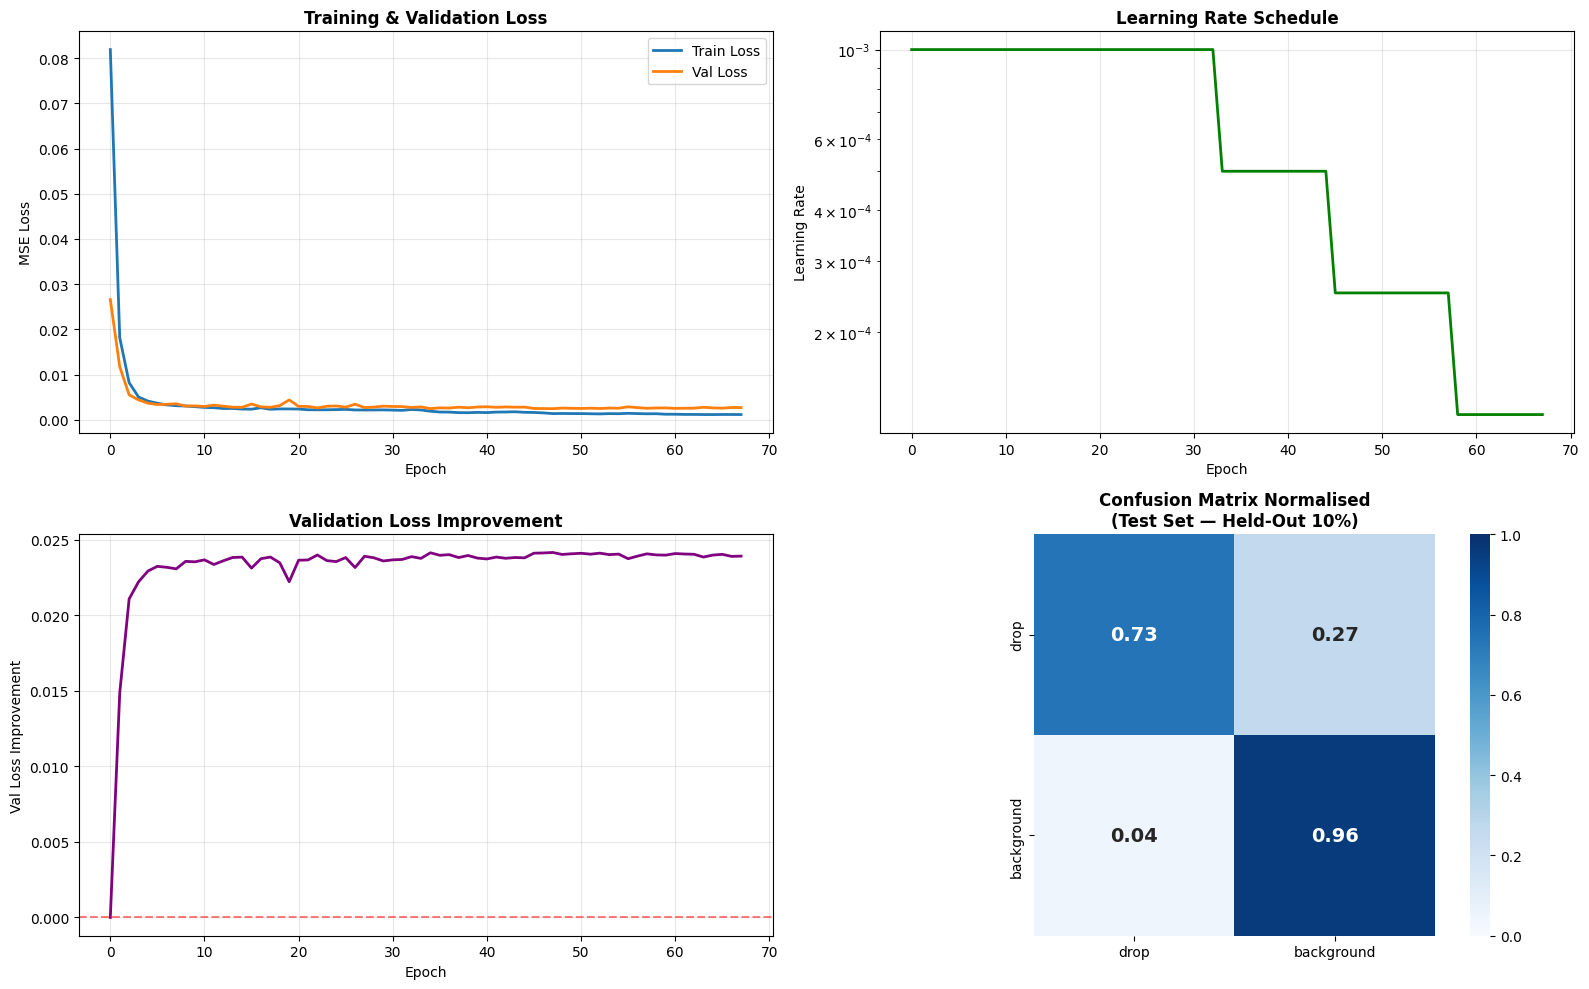


FINAL PERFORMANCE METRICS — TEST SET
Accuracy:  0.8931  (89.31%)
Precision: 0.9011  (90.11%)
Recall:    0.9556  (95.56%)
F1-Score:  0.9276  (92.76%)


In [15]:
"""
Final Performance Plot — Training curves + Test Confusion Matrix
"""
def generate_performance_plots(model, val_loader, test_loader, device, history, threshold=0.3):
    
    model.eval()
    all_gt, all_pred = [], []
    with torch.no_grad():
        for images, heatmaps in tqdm(test_loader, desc="Test CM"):
            images = images.to(device); heatmaps = heatmaps.to(device)
            outputs = model(images)
            for i in range(images.size(0)):
                all_gt.append(int((heatmaps[i].max() > 0.1).cpu().item()))
                all_pred.append(int(outputs[i].max().cpu().item() > threshold))

    all_gt = np.array(all_gt); all_pred = np.array(all_pred)
    cm = confusion_matrix(all_gt, all_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    epochs = len(history['train_loss'])
    epoch_range = range(epochs)

    fig = plt.figure(figsize=(16, 10))

    
    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(epoch_range, history['train_loss'], label='Train Loss', lw=2, color='#1f77b4')
    ax1.plot(epoch_range, history['val_loss'],   label='Val Loss',   lw=2, color='#ff7f0e')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE Loss')
    ax1.set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    
    ax2 = plt.subplot(2, 2, 2)
    ax2.plot(epoch_range, history['learning_rates'], lw=2, color='green')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Learning Rate')
    ax2.set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
    ax2.set_yscale('log'); ax2.grid(True, alpha=0.3)

    
    ax3 = plt.subplot(2, 2, 3)
    improvements = [history['val_loss'][0] - l for l in history['val_loss']]
    ax3.plot(epoch_range, improvements, lw=2, color='purple')
    ax3.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    ax3.set_xlabel('Epoch'); ax3.set_ylabel('Val Loss Improvement')
    ax3.set_title('Validation Loss Improvement', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)

    
    ax4 = plt.subplot(2, 2, 4)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax4, square=True,
                vmin=0, vmax=1, annot_kws={'fontsize': 14, 'fontweight': 'bold'},
                xticklabels=['drop','background'], yticklabels=['drop','background'])
    ax4.set_title('Confusion Matrix Normalised\n(Test Set — Held-Out 10%)',
                  fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('performance_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    accuracy  = (tp+tn)/(tp+tn+fp+fn)
    precision = tp/(tp+fp) if (tp+fp)>0 else 0
    recall    = tp/(tp+fn) if (tp+fn)>0 else 0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0
    print("\n" + "="*60)
    print("FINAL PERFORMANCE METRICS — TEST SET")
    print("="*60)
    print(f"Accuracy:  {accuracy:.4f}  ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}  ({precision*100:.2f}%)")
    print(f"Recall:    {recall:.4f}  ({recall*100:.2f}%)")
    print(f"F1-Score:  {f1:.4f}  ({f1*100:.2f}%)")
    print("="*60)
    return cm_norm


cm_normalized = generate_performance_plots(
    model, val_loader, test_loader, device, history, threshold=0.3
)
